In [1]:
# import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from my_nn import activations, loss, metrics, nn 


##### First we generate sample data for each task. We use the same input features for all tasks to keep things simple.
##### Then for binary classification we create a parabolic decision boundary.
##### For multiclass classification we use a hyperbolic decision boundary to create three classes.
##### For regression we use a parabolic surface.

In [2]:
# create data sets to use
# for all 3 pick 10000 random points in the square [-5,5]x[-5,5]
X = np.random.uniform(-5, 5, size=(10000, 2))
# for binary classification, label points above the curve y = x^2 - 2 as 1, below as 0
y_binary = (X[:,1] - X[:,0] ** 2 >= -2).astype(int) 
# for multi-class classification we will use the hyperbola y^2 - x^2 = 3 to create 3 classes
mask1 = (X[:,1] ** 2 - X[:,0] ** 2 >= 3) & (X[:,1] > 0)
mask2 = (X[:,1] ** 2 - X[:,0] ** 2 >= 3)  & (X[:,1] < 0)
y_multiclass = mask1  + 2 * mask2
# for regression we will use the function y = x^2 + y^2
y_regression = np.sum(X**2, axis=1)

##### Next we visualize the data for each task

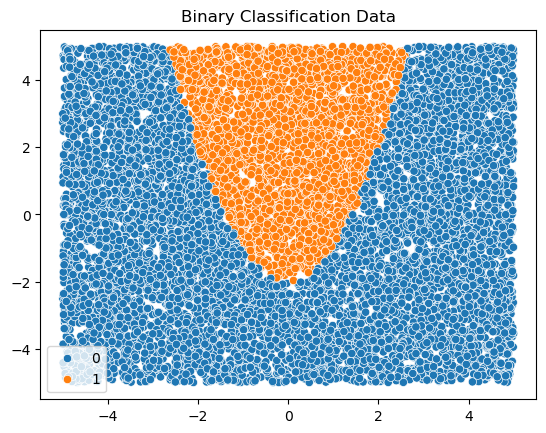

In [3]:
# Binary classification data plot
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_binary)
plt.title("Binary Classification Data")
plt.show()

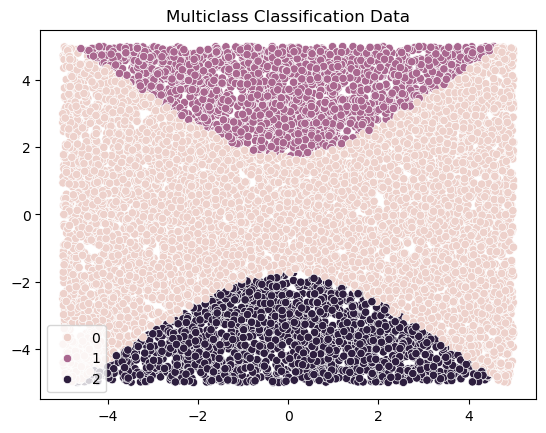

In [4]:
# multiclass classification data plot
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_multiclass)
plt.title("Multiclass Classification Data")
plt.show()

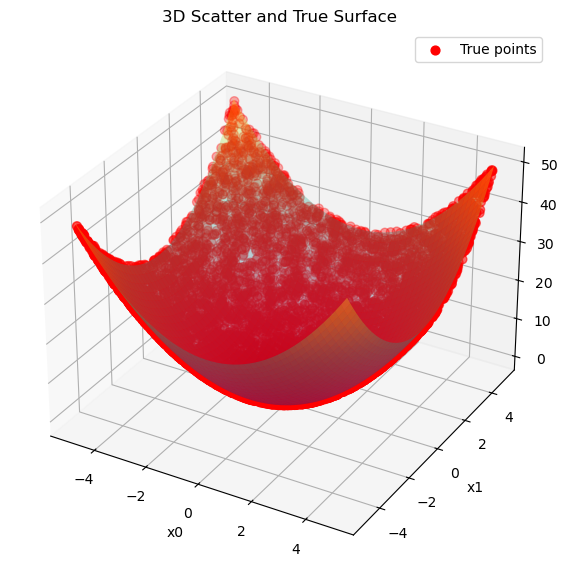

In [5]:
# Regression data plot
# Create grid for surface

x0_grid = np.linspace(-5, 5, 50)
x1_grid = np.linspace(-5, 5, 50)
x0_mesh, x1_mesh = np.meshgrid(x0_grid, x1_grid)
y_mesh = x0_mesh**2 + x1_mesh**2  # true surface
# for the scatterplot we'll choose a random sample of 1000 points 
#indices = np.random.choice(X.shape[0], size=1000, replace=False)
#X_sample = X[indices]
#y_sample = y_regression[indices]
# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Surface for true function
ax.plot_surface(x0_mesh, x1_mesh, y_mesh, alpha=0.3, cmap='viridis')

# Scatter true points
ax.scatter(X[:, 0], X[:, 1], y_regression, color='red', label='True points', s=40)



ax.set_xlabel('x0')
ax.set_ylabel('x1')
ax.set_zlabel('y')
ax.set_title('3D Scatter and True Surface')
ax.legend()

plt.show()

##### Next we set up the models. We will use the same basic architecture for all tasks, but change the output layer and loss function as appropriate for each task.


In [6]:
model_binary = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 1, activation="sigmoid")
)

model_multiclass = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 3, activation="identity")
)

model_regression = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 1, activation="identity")
)

In [7]:
# we create a training and test split for each data set.
X_binary_train,X_binary_test,y_binary_train,y_binary_test = nn.train_test_split(X,y_binary, train_size=0.8)
X_multiclass_train,X_multiclass_test,y_multiclass_train,y_multiclass_test = nn.train_test_split(X,y_multiclass, train_size=0.8)
X_regression_train,X_regression_test,y_regression_train,y_regression_test = nn.train_test_split(X,y_regression, train_size=0.8)

##### Next , train all 3 models for 200 epochs each, using a batch size of 32 and a learning rate of 0.01.

In [8]:
history_binary = model_binary.fit(X_binary_train, y_binary_train, epochs=200 ,learning_rate=0.01, batch_size=32, verbose=False, loss_fn="binary_cross_entropy", metric=metrics.accuracy, val_size = 0.2)

Epoch 1 complete. Average Loss: 0.6251 , accuracy 0.7748 -  Validation Loss: 0.4331, Validation accuracy 0.7512
Epoch 2 complete. Average Loss: 0.3737 , accuracy 0.8386 -  Validation Loss: 0.3634, Validation accuracy 0.8269
Epoch 3 complete. Average Loss: 0.3249 , accuracy 0.8609 -  Validation Loss: 0.3272, Validation accuracy 0.8544
Epoch 4 complete. Average Loss: 0.2965 , accuracy 0.8781 -  Validation Loss: 0.3039, Validation accuracy 0.8719
Epoch 5 complete. Average Loss: 0.2778 , accuracy 0.8897 -  Validation Loss: 0.2876, Validation accuracy 0.8819
Epoch 6 complete. Average Loss: 0.2645 , accuracy 0.8925 -  Validation Loss: 0.2756, Validation accuracy 0.8869
Epoch 7 complete. Average Loss: 0.2545 , accuracy 0.8984 -  Validation Loss: 0.2663, Validation accuracy 0.8906
Epoch 8 complete. Average Loss: 0.2466 , accuracy 0.9011 -  Validation Loss: 0.2586, Validation accuracy 0.8944
Epoch 9 complete. Average Loss: 0.2401 , accuracy 0.9017 -  Validation Loss: 0.2523, Validation accuracy

In [9]:
history_multiclass = model_multiclass.fit(X_multiclass_train, y_multiclass_train, epochs=200 ,learning_rate=0.01, batch_size=32, verbose=False, loss_fn="categorical_cross_entropy", metric=metrics.accuracy, val_size = 0.2)

Epoch 1 complete. Average Loss: 0.9302 , accuracy 0.6361 -  Validation Loss: 0.8727, Validation accuracy 0.6275
Epoch 2 complete. Average Loss: 0.8121 , accuracy 0.6361 -  Validation Loss: 0.7846, Validation accuracy 0.6275
Epoch 3 complete. Average Loss: 0.7336 , accuracy 0.7347 -  Validation Loss: 0.7141, Validation accuracy 0.7156
Epoch 4 complete. Average Loss: 0.6684 , accuracy 0.8108 -  Validation Loss: 0.6535, Validation accuracy 0.7887
Epoch 5 complete. Average Loss: 0.6117 , accuracy 0.8406 -  Validation Loss: 0.6006, Validation accuracy 0.8306
Epoch 6 complete. Average Loss: 0.5614 , accuracy 0.8566 -  Validation Loss: 0.5537, Validation accuracy 0.8506
Epoch 7 complete. Average Loss: 0.5165 , accuracy 0.8739 -  Validation Loss: 0.5113, Validation accuracy 0.8725
Epoch 8 complete. Average Loss: 0.4764 , accuracy 0.8836 -  Validation Loss: 0.4739, Validation accuracy 0.8794
Epoch 9 complete. Average Loss: 0.4410 , accuracy 0.8933 -  Validation Loss: 0.4408, Validation accuracy

In [10]:
history_regression = model_regression.fit(X_regression_train, y_regression_train, epochs=200 ,learning_rate=0.01, batch_size=32, verbose=False, loss_fn="mse", metric=metrics.mse, val_size=0.2)

Epoch 1 complete. Average Loss: 28.2942 , mse 16.5794 -  Validation Loss: 15.7956, Validation mse 15.7956
Epoch 2 complete. Average Loss: 15.4366 , mse 14.6199 -  Validation Loss: 14.0245, Validation mse 14.0245
Epoch 3 complete. Average Loss: 13.5515 , mse 12.5112 -  Validation Loss: 12.0137, Validation mse 12.0137
Epoch 4 complete. Average Loss: 11.7803 , mse 10.9737 -  Validation Loss: 10.6022, Validation mse 10.6022
Epoch 5 complete. Average Loss: 10.1698 , mse 9.2289 -  Validation Loss: 8.9962, Validation mse 8.9962
Epoch 6 complete. Average Loss: 8.5510 , mse 7.7584 -  Validation Loss: 7.4941, Validation mse 7.4941
Epoch 7 complete. Average Loss: 7.0622 , mse 6.3322 -  Validation Loss: 6.1458, Validation mse 6.1458
Epoch 8 complete. Average Loss: 5.6795 , mse 4.8222 -  Validation Loss: 4.7378, Validation mse 4.7378
Epoch 9 complete. Average Loss: 4.4437 , mse 3.8246 -  Validation Loss: 3.8013, Validation mse 3.8013
Epoch 10 complete. Average Loss: 3.4553 , mse 3.0449 -  Validatio

##### Look a the training history for each model. We will plot the training and validation loss and accuracy (where applicable) over epochs.

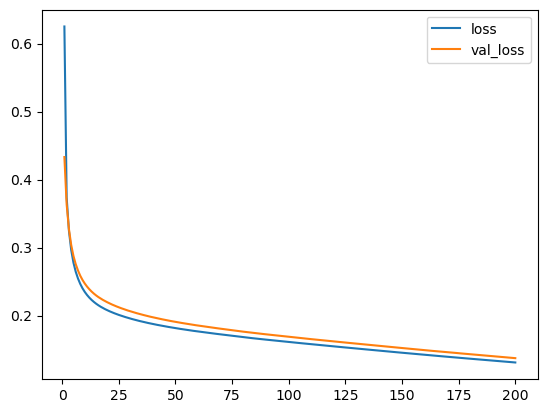

In [11]:
# Plot training & validation loss values for binary classification
nn.plot_history(history_binary, "loss", "val_loss")

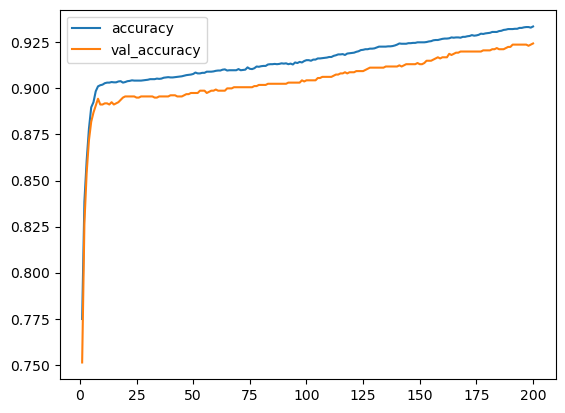

In [12]:
# plot training and validation accuracy for binary classification
nn.plot_history(history_binary, "accuracy", "val_accuracy")

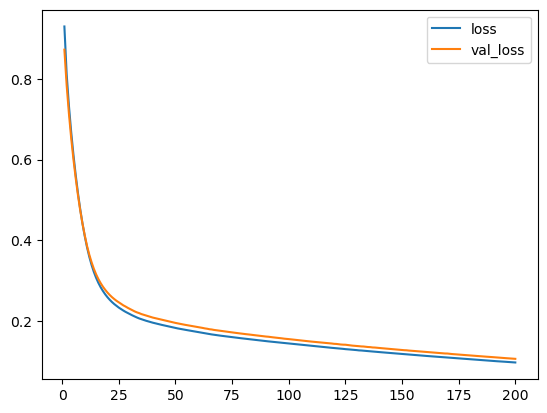

In [13]:
# plot training & validation loss values for multiclass classification
nn.plot_history(history_multiclass, "loss", "val_loss")

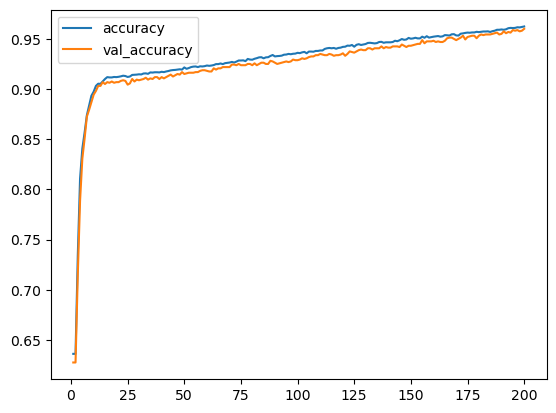

In [14]:
# plot training & validation accuracy for multiclass classification
nn.plot_history(history_multiclass, "accuracy", "val_accuracy")

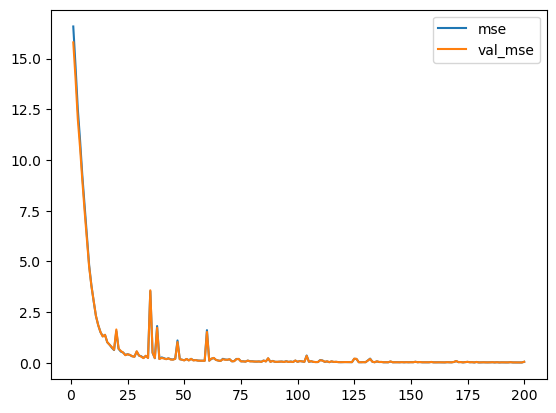

In [15]:
# plot mse loss for regression
nn.plot_history(history_regression, "mse", "val_mse")

First we look at basic metrics on the performance on unseen test set. 

In [16]:
y_binary_pred_test = model_binary.predict(X_binary_test)
y_multiclass_pred_test = model_multiclass.predict(X_multiclass_test)
y_regression_pred_test = model_regression.predict(X_regression_test)

In [17]:
# convert the classification predictions to class labels
y_binary_pred_labels = (y_binary_pred_test >= 0.5).astype(int)
y_multiclass_pred_labels = np.argmax(y_multiclass_pred_test, axis=1)

In [19]:
binary_acc = metrics.accuracy(y_binary_test, y_binary_pred_labels)
binary_recall = metrics.recall(y_binary_test, y_binary_pred_labels)
binary_precision = metrics.precision(y_binary_test, y_binary_pred_labels)
binary_f1 = metrics.f1_score(y_binary_test, y_binary_pred_labels)
binary_spec = metrics.specificity(y_binary_test, y_binary_pred_labels)
binary_balanced = metrics.balanced_accuracy(y_binary_test, y_binary_pred_labels)
multiclass_acc = metrics.accuracy(y_multiclass_test, y_multiclass_pred_labels)
regression_mse = metrics.mse(y_regression_test, y_regression_pred_test)
regression_r2 = metrics.r2_score(y_regression_test, y_regression_pred_test)

In [20]:
print(f"Binary classification accuracy: {binary_acc:.4f}")
print(f"Binary recall: {binary_recall: .4f}")
print(f"Binary precision: {binary_precision: .4f}")
print(f"Binary F1 score: { binary_f1 : .4f}")
print(f"Binary specificity : {binary_spec: .4f}")
print(f"Binary balanced accuracy : {binary_balanced: .4f}")
print(f"Multiclass classification accuracy: {multiclass_acc:.4f}")
print(f"Regression MSE: {regression_mse:.4f}")  
print(f"Regression R^2: {regression_r2:.4f}")

Binary classification accuracy: 0.9395
Binary recall:  0.9710
Binary precision:  0.7699
Binary F1 score:  0.8588
Binary specificity :  0.9321
Binary balanced accuracy :  0.9516
Multiclass classification accuracy: 0.9630
Regression MSE: 0.0600
Regression R^2: 0.9995


##### Finally we visualize the true decision boundaries for the classification tasks and the true surface for the regression task, along with the model predictions.

In [21]:
# get predictions for full data set
y_binary_pred = model_binary.predict(X)
y_multiclass_pred = model_multiclass.predict(X)
y_regression_pred = model_regression.predict(X)

y_binary_pred_labels = (y_binary_pred >= 0.5).astype(int)
y_multiclass_pred_labels = np.argmax(y_multiclass_pred, axis=1)

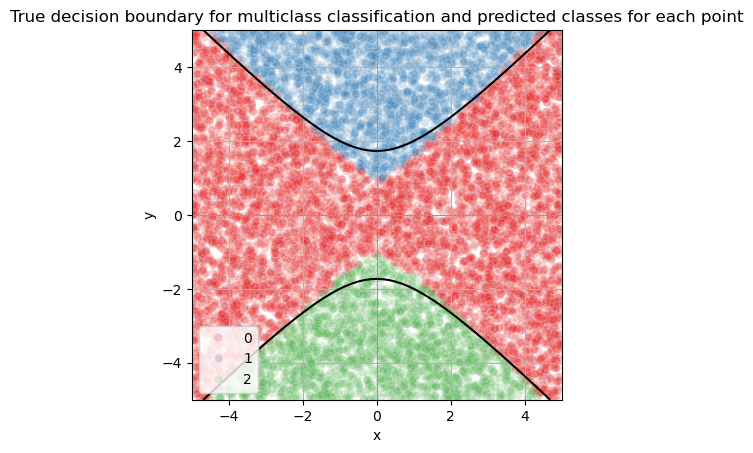

In [22]:



# Create a grid of x and y values
x = np.linspace(-5, 5, 400)
y = np.linspace(-5, 5, 400)
X_vals, Y_vals = np.meshgrid(x, y)

# Define the hyperbola equation
F = Y_vals**2- X_vals**2 

# Plot the hyperbola using contour
plt.contour(X_vals, Y_vals, F, [3], colors='k', linestyles='solid')
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_multiclass_pred_labels.ravel(), palette='Set1', alpha=0.2)

# Add labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title("True decision boundary for multiclass classification and predicted classes for each point")
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box') # Ensure proper aspect ratio
plt.show()

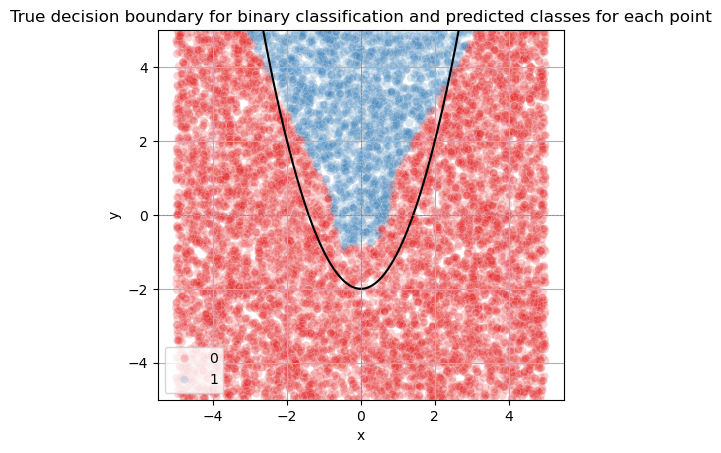

In [23]:
x = np.linspace(-5, 5, 400)
y = x**2 - 2
plt.plot(x, y, color='k', linestyle='solid')
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_binary_pred_labels.ravel(), palette='Set1', alpha=0.2)

# Add labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title("True decision boundary for binary classification and predicted classes for each point")
plt.grid(True)
plt.ylim(-5,5)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box') # Ensure proper aspect ratio
plt.show()

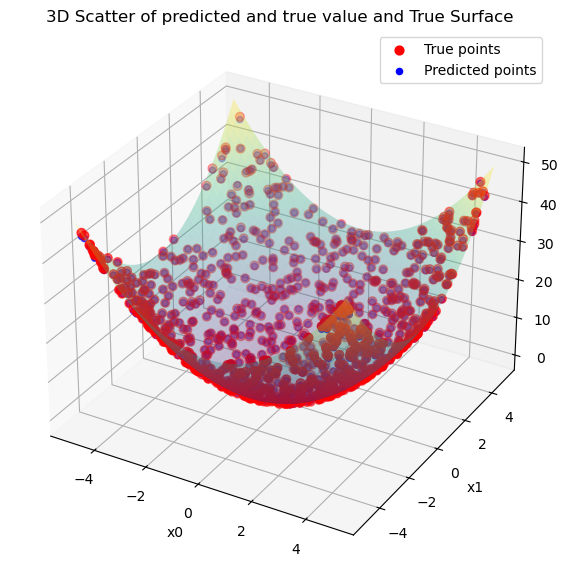

In [24]:
# Regression data plot
# Create grid for surface
idx = np.random.choice(len(X), size=1000, replace=False)
X_sample = X[idx]
y_sample = y_regression[idx]
y_pred_sample = y_regression_pred[idx]
x0_grid = np.linspace(-5, 5, 50)
x1_grid = np.linspace(-5, 5, 50)
x0_mesh, x1_mesh = np.meshgrid(x0_grid, x1_grid)
y_mesh = x0_mesh**2 + x1_mesh**2  # true surface
# for the scatterplot we'll choose a random sample of 1000 points 
#indices = np.random.choice(X.shape[0], size=1000, replace=False)
#X_sample = X[indices]
#y_sample = y_regression[indices]
# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Surface for true function
ax.plot_surface(x0_mesh, x1_mesh, y_mesh, alpha=0.3, cmap='viridis')

# Scatter true points
ax.scatter(X_sample[:, 0], X_sample[:, 1], y_sample.ravel(), color='red', label='True points', s=40)
# Scatter predicted points
ax.scatter(X_sample[:, 0], X_sample[:, 1], y_pred_sample.ravel(), color='blue', label='Predicted points', s=20)



ax.set_xlabel('x0')
ax.set_ylabel('x1')
ax.set_zlabel('y')
ax.set_title('3D Scatter of predicted and true value and True Surface')
ax.legend()

plt.show()

##### Finally a little exploration of residuals and confusion matrices for the regression and multiclass classification tasks.


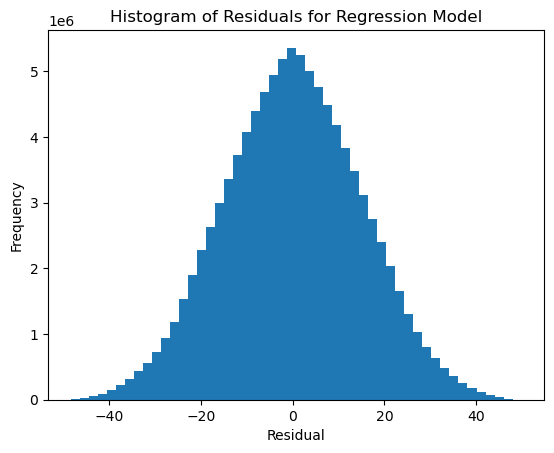

In [25]:
residuals = (y_regression - y_regression_pred).flatten()
plt.hist(residuals, bins=50)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals for Regression Model")
plt.show()


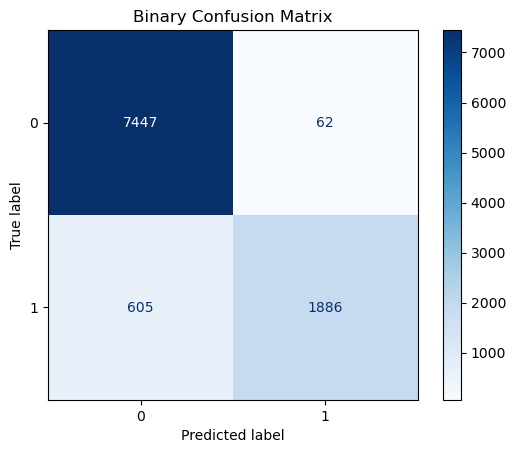

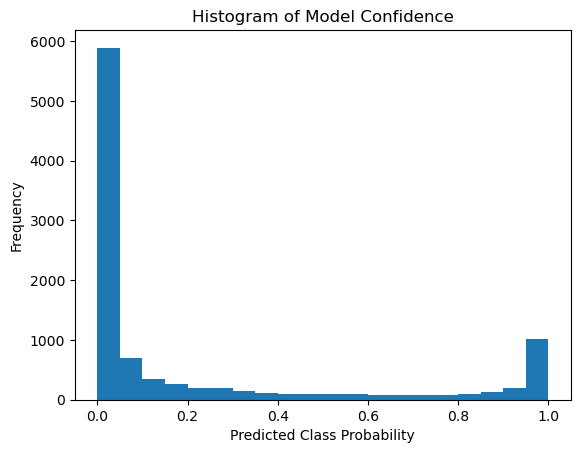

In [26]:

cm = confusion_matrix(y_binary, y_binary_pred_labels)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Binary Confusion Matrix")
plt.show()

# Step 4: histogram of max probabilities (confidence)
max_probs = np.max(y_binary_pred, axis=1)
plt.hist(max_probs, bins=20)
plt.xlabel("Predicted Class Probability")
plt.ylabel("Frequency")
plt.title("Histogram of Model Confidence")
plt.show()

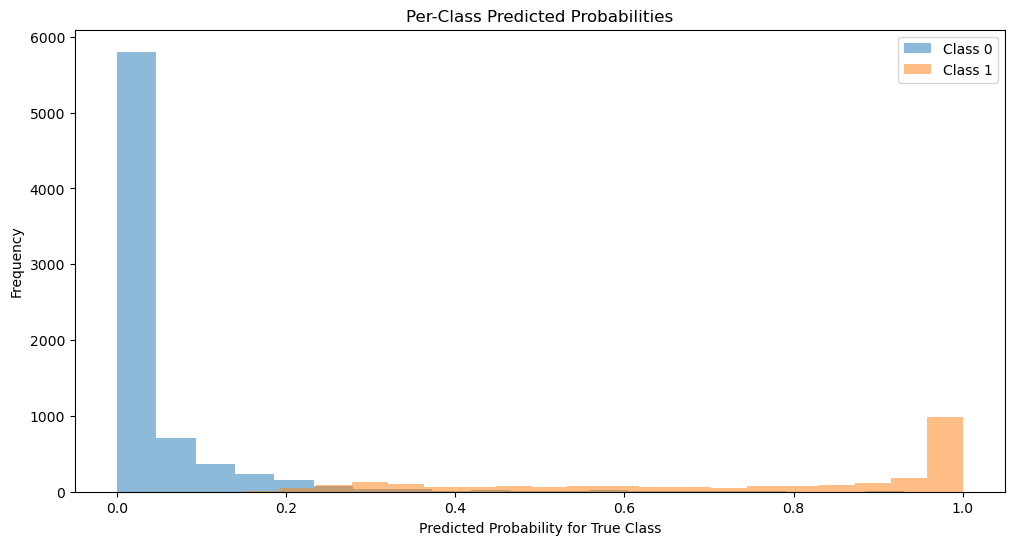

In [27]:
# y_prob: softmax probabilities from your model (n_samples, n_classes)
# y_true: true class labels (integers 0..n_classes-1)
n_classes = 2

plt.figure(figsize=(12, 6))

for cls in range(n_classes):
    # select probabilities for samples whose true label is cls
    cls_probs = y_binary_pred[y_binary.ravel() == cls]
    
    plt.hist(cls_probs, bins=20, alpha=0.5, label=f"Class {cls}")

plt.xlabel("Predicted Probability for True Class")
plt.ylabel("Frequency")
plt.title("Per-Class Predicted Probabilities")
plt.legend()
plt.show()

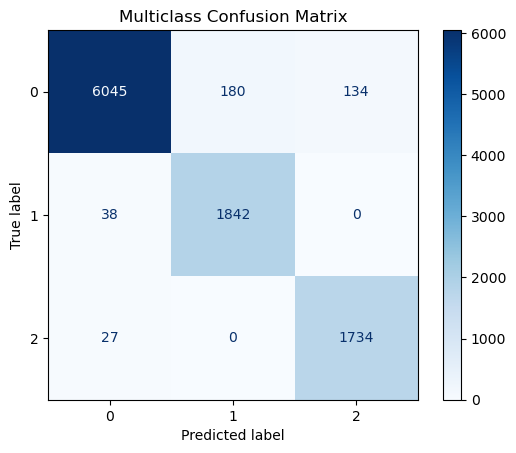

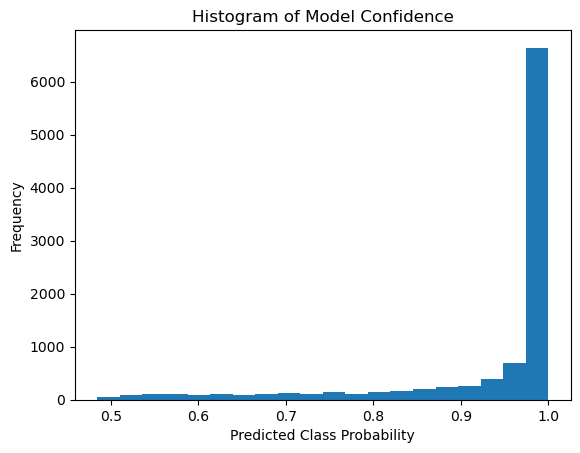

In [28]:



# y_multiclass_pred: raw logits from your model
# y_multiclass_true: true class labels (integers 0,1,2,...)

# Step 1: softmax the logits
def softmax(z):
    e_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e_z / np.sum(e_z, axis=1, keepdims=True)

y_prob = softmax(y_multiclass_pred)

# Step 2: predicted classes
y_pred_labels = np.argmax(y_prob, axis=1)

# Step 3: confusion matrix
cm = confusion_matrix(y_multiclass, y_pred_labels)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass Confusion Matrix")
plt.show()

# Step 4: histogram of max probabilities (confidence)
max_probs = np.max(y_prob, axis=1)
plt.hist(max_probs, bins=20)
plt.xlabel("Predicted Class Probability")
plt.ylabel("Frequency")
plt.title("Histogram of Model Confidence")
plt.show()


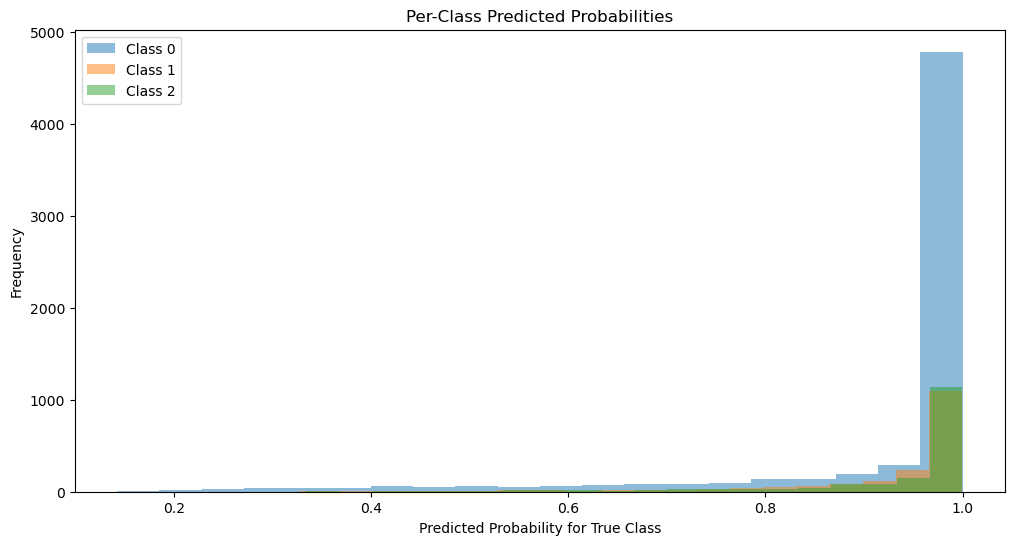

In [29]:


# y_prob: softmax probabilities from your model (n_samples, n_classes)
# y_true: true class labels (integers 0..n_classes-1)
n_classes = y_prob.shape[1]

plt.figure(figsize=(12, 6))

for cls in range(n_classes):
    # select probabilities for samples whose true label is cls
    cls_probs = y_prob[y_multiclass.ravel() == cls, cls]
    
    plt.hist(cls_probs, bins=20, alpha=0.5, label=f"Class {cls}")

plt.xlabel("Predicted Probability for True Class")
plt.ylabel("Frequency")
plt.title("Per-Class Predicted Probabilities")
plt.legend()
plt.show()
